# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/docs/stable/torchvision/datasets.html#cifar)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
import random

# set the seed for reproducibility of the data split
SEED = 42 
BATCH_SIZE = 64
NUM_WORKERS = 0 # 0 means no multiprocessing - best for notebook

# Define transforms with data augmentation
train_transformer = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(), # data augmentation: this randomly flips the image horizontally
    torchvision.transforms.RandomRotation(10), # data augmentation: this randomly rotates the image by 10 degrees
    torchvision.transforms.ToTensor(), # convert the images to tensors
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalize the images to have a mean of 0 and a standard deviation of 1
])

# test set and validation set do not have data augmentation
test_transformer = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(), # convert the images to tensors
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # normalize the images to have a mean of 0 and a standard deviation of 1
])


# train and validation set have different transforms
train_data = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transformer
)
val_data = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=test_transformer
)

full_size = len(train_data) # full size of the training plus validation set (not the test set)
train_size = int(full_size * 0.8)
val_size = full_size - train_size

# some manual shuffling and splitting here so we don't do data augmentation on the validation set
generator = torch.Generator().manual_seed(SEED) 
indices = torch.randperm(full_size, generator=generator) # make sure the shuffling is the same for train and validation set
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# now do the actual split 
train_set = torch.utils.data.Subset(train_data, train_indices)
val_set = torch.utils.data.Subset(val_data, val_indices)

# we are using the test set from the CIFAR-10 dataset that is already split out of the box
test_set = torchvision.datasets.CIFAR10(root='./test_data', train=False, download=True, transform=test_transformer)
test_size = len(test_set)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Training samples: {len(train_set)}, Validation samples: {len(val_set)}, Test samples: {len(test_set)}')

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Training samples: 40000, Validation samples: 10000, Test samples: 10000


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [3]:
# This class is based on the code from the Pytorch forum: 
# https://discuss.pytorch.org/t/simple-way-to-inverse-transform-normalization/4821/6
# and we need it to visualize the images in the original format that we normalized to tensors

class NormalizeInverse(torchvision.transforms.Normalize):
    """
    Undoes the normalization and returns the reconstructed images in the input domain.
    """

    def __init__(self, mean, std):
        mean = torch.as_tensor(mean)
        std = torch.as_tensor(std)
        std_inv = 1 / (std + 1e-7)
        mean_inv = -mean * std_inv
        super().__init__(mean=mean_inv, std=std_inv)

    def __call__(self, tensor):
        tensor = super().__call__(tensor.clone())

        # Additional code we need here that was not in the original code from the Pytorch forum:
        # The permute is to change the shape of the image from (32, 32, 3) to (3, 32, 32)
        tensor = tensor.permute(1, 2, 0)
        # we also need to clip the values to be between 0 and 1 otherwise we will get warnings like "Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07843127..1.0000001]."
        tensor = tensor.clamp(0, 1)
        
        return tensor


# initialize the new denormalize object with the mean and std of the dataset
denormalize = NormalizeInverse((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

In [4]:
def show5(img_loader):
    dataiter = iter(img_loader)
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]

    for i in range(5):
        print(classes[labels[i]])
        # denormalize the image and clamp and permute the image to the correct format
        image = denormalize(images[i])
        plt.imshow(image)
        plt.show()

In [5]:
# Explore data

print(f'Training samples: {len(train_set)}')
print(f'Validation samples: {len(val_set)}')
print(f'Test samples: {len(test_set)}')
print(f'Full training set samples: {len(train_data)}\n')

# get some sample images and labels to show the shape of the data
sample_images, sample_labels = next(iter(train_loader))
print(f'Batch shape: {sample_images.shape}')
print(f'Single image shape: {sample_images[0].shape}')
print(f'Raw CIFAR-10 array shape: {train_data.data.shape}\n')



Training samples: 40000
Validation samples: 10000
Test samples: 10000
Full training set samples: 50000

Batch shape: torch.Size([64, 3, 32, 32])
Single image shape: torch.Size([3, 32, 32])
Raw CIFAR-10 array shape: (50000, 32, 32, 3)



In [6]:
# lets take a look at the data in of a couple of the images in the training set in raw format and normalized as tensor
print(f'A raw training image: \n{train_data.data[0]}\n')
print(f'An image normalized as tensor): \n{sample_images[0]}\n')

A raw training image: 
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]

An image normalized as tensor): 
tensor([[[-1.0000, -0.4745, -0.1373,  ..., -1.0000, -1.0000, -1.0000],
         [-1.0000,  0.1843,  0.2392,  ...,  0.2000,  0.2471,  0.0824],
         [-1.0000,  0.0824, -0.0510,  ...,  0.1765,  0.1686, -0.0275],
         ...,
         [ 0.2078, -0.0667, -0.7647,  ...,  0.4118,  0.3333, -1.0000],
         [ 0.33

Five random images from the test set:

cat


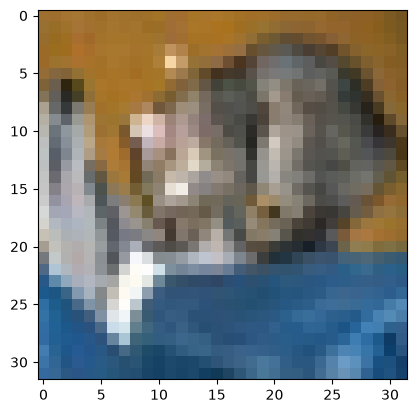

ship


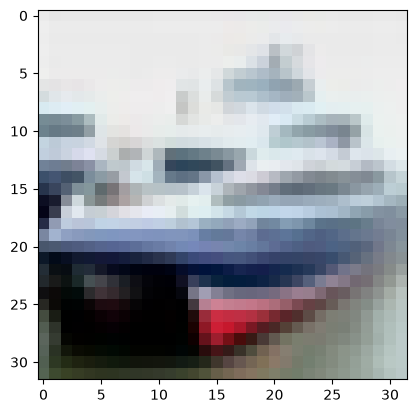

ship


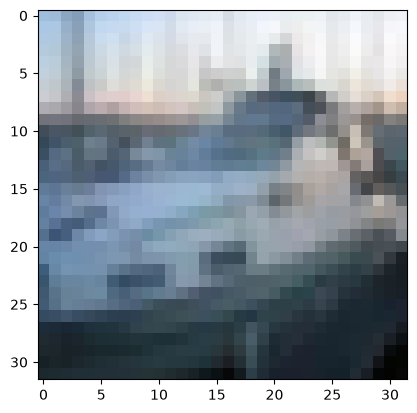

plane


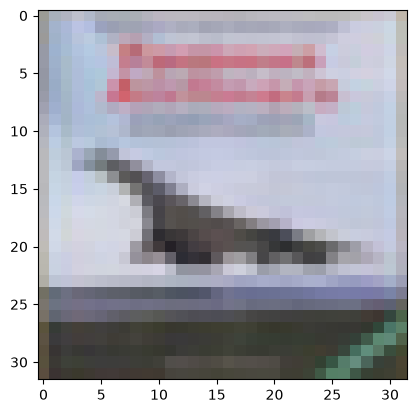

frog


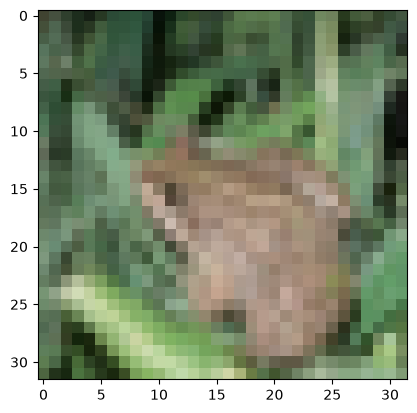

In [7]:
print('Five random images from the test set:\n')
# show5(train_loader)
# show5(val_loader)
show5(test_loader)

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [ ]:
class Model(nn.Module):

    # initialize the model (and also call the parent class's constructor)
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(

          # input tensor shape: (3, 32, 32) — channels, height, width

          # Convolutional layer 1 (3 input channels, 32 output channels, kernel size 3, padding 1)
          nn.Conv2d(3, 32, 3, padding=1),
          # ReLU activation function
          nn.ReLU(),

          # feature map shape: (32, 32, 32)
          # 32 channels, 32 height, 32 width

          # Max pooling layer downsamples spatial dimensions by 2x
          nn.MaxPool2d(2, 2),

          # feature map shape: (32, 16, 16)
          # 32 channels, 16 height, 16 width

          # Convolutional layer 2 (32 input channels, 64 output channels, kernel size 3, padding 1)
          nn.Conv2d(32, 64, 3, padding=1),
          # ReLU activation function
          nn.ReLU(),

          # feature map shape: (64, 16, 16)
          # 64 channels, 16 height, 16 width

          # Max pooling layer downsamples spatial dimensions by 2x
          nn.MaxPool2d(2, 2),

          # feature map shape: (64, 8, 8)
          # 64 channels, 8 height, 8 width

          # Convolutional layer 3
          nn.Conv2d(64, 128, 3, padding=1),
          # ReLU activation function
          nn.ReLU(),

          # feature map shape: (128, 8, 8)
          # 128 channels, 8 height, 8 width

          # flatten feature map into a 1D vector for the linear layers
          nn.Flatten(),

          # feature vector length: 128 * 8 * 8 = 8192

          # Linear layer 1
          nn.Linear(8192, 1024),
          # ReLU activation function (relu is 0 for negative values and x for positive values)
          nn.ReLU(),

          # feature vector length: 1024

          # Linear layer 2
          nn.Linear(1024, 512),
          # ReLU activation function
          nn.ReLU(),

          # feature vector length: 512

          # Linear layer 3 (output logits, one score per class)
          nn.Linear(512, 10),

          # logits shape: (10,)
        )

    # forward pass
    def forward(self, x):
      return self.network(x)

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [9]:
# define the loss function: cross entropy loss
criterion = nn.CrossEntropyLoss()


## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [ ]:
# set some parameters
epochs = 10 # when stop_when_val_loss_does_not_improve is True it may stop earlier 
stop_when_val_loss_does_not_improve = True # early stopping feature if the validation loss does not improve after a epoch

# set the model
model = Model()

# define the optimizer: Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# set the device: CUDA, Apple MPS, or CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu - this may take a while ...')

model.to(device)
print(f'Using device: {device}\n')


# function to calculate the loss and accuracy of the model
def evaluate(loader):
    model.eval() # set the model to evaluation mode
    # initialize the running loss, correct, and total to 0
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # disable gradient calculation because we are not training
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device) # move the images and labels to the device (GPU, MPS, or CPU)
            logits = model(images)
            # calculate the loss from logits (what the model predicts) and labels (what the model should predict)
            loss = criterion(logits, labels) 

            running_loss += loss.item() # the .item() method returns the value of the loss as a float
            preds = logits.argmax(dim=1) # get the predicted class from the logits. argmax returns the index of the maximum value in the logits
            correct += (preds == labels).sum().item() # count the number of correct predictions
            total += labels.size(0) # count the number of total predictions

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


# set empty lists for the training loss, validation loss, and validation accuracy
train_losses = []
val_losses = []
val_accuracies = []

from tqdm.auto import tqdm

# initialize the best validation loss to infinity so that the first validation loss will be lower
best_val_loss = float('inf')

# loop over the number of epochs 0..epochs-1
for epoch in range(epochs):
    model.train() # set the model to training mode
    running_loss = 0.0

    # batch_loop is a tqdm object (for the progress bar) that iterates over the train_loader it holds the images and labels
    batch_loop = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')

    # i is the index of the batch
    i = 0

    for images, labels in batch_loop:
        i += 1
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        # print(f'running_loss: {running_loss} i {i}  batch_loop length {len(batch_loop)}')
        batch_loop.set_postfix(train_loss=f'{running_loss/i:.4f}') # add the training loss to the end of the progress bar

    train_loss = running_loss / len(train_loader)
    val_loss, val_accuracy = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch {epoch + 1}/{epochs}: Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')

    # stop training if the validation loss does not improve and we set stop_when_val_loss_does_not_improve to True
    if stop_when_val_loss_does_not_improve: 
        if (val_loss < best_val_loss):
            torch.save(model.state_dict(), 'model.pth') # save the model in case the next epoch is worse
            best_val_loss = val_loss
        else:      
            print('Early stopping triggered because the validation loss did not improve and it starts to overfit. The model from the previous epoch has been saved as model.pth. ')
            break    

# save the model at the end if we don't use early stopping
if not stop_when_val_loss_does_not_improve:
    torch.save(model.state_dict(), 'model.pth')
    print('The model has been saved as model.pth.')


Using device: mps



Epoch 1/10:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/10: Training Loss: 1.4540, Validation Loss: 1.1518, Validation Accuracy: 58.43%


Epoch 2/10:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 2/10: Training Loss: 1.0412, Validation Loss: 0.9172, Validation Accuracy: 67.63%


...

Epoch 5/10: Training Loss: 0.6530, Validation Loss: 0.7389, Validation Accuracy: 74.63%


Epoch 6/10:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 6/10: Training Loss: 0.5714, Validation Loss: 0.7126, Validation Accuracy: 75.54%


Epoch 7/10:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 7/10: Training Loss: 0.5053, Validation Loss: 0.7307, Validation Accuracy: 75.71%
Early stopping triggered because the validation loss did not improve and it starts to overfit. The model from the previous epoch has been saved as model.pth. 


Plot the training loss (and validation loss/accuracy, if recorded).

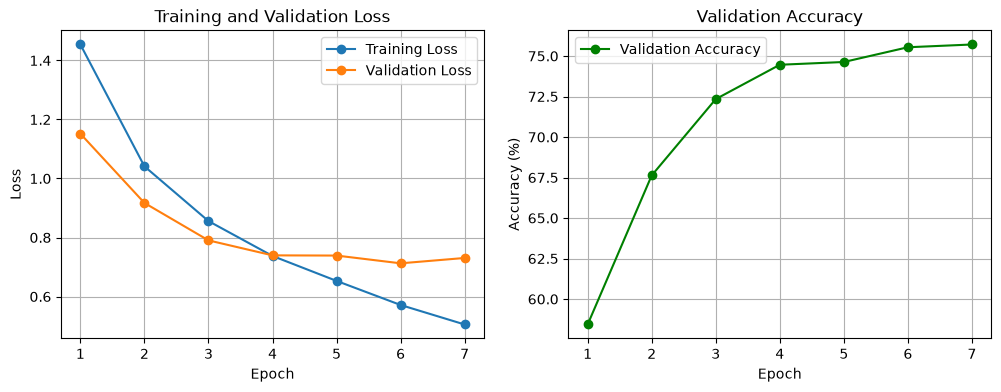

In [11]:
# define the plot_training_history function that plots the training loss and validation loss
from matplotlib.ticker import MaxNLocator

if len(train_losses) > 0:

    epochs_range = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs_range, train_losses, marker='o', label='Training Loss')
    ax1.plot(epochs_range, val_losses, marker='o', label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True)) # otherwise the x-axis would show numbers like epoch 1.5 etc
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs_range, val_accuracies, marker='o', color='green', label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Validation Accuracy')
    ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2.legend()
    ax2.grid(True)

    plt.show()





## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [12]:
# load the saved model first 
model.load_state_dict(torch.load('model.pth', map_location=device))
model.eval()

test_loss, test_accuracy = evaluate(test_loader)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')

if test_accuracy > 70:
    print('\nWoohoo! Over 70% accuracy!')
else:
    print('\nDoh!')


Test Loss: 0.7237
Test Accuracy: 76.17%

Woohoo! Over 70% accuracy!


## Saving your model
Using `torch.save`, save your model for future loading.

In [13]:
# We are using optional early stopping feature so we need to save the model in the training loop above under "Running your Neural Network" and not here.
#torch.save(model.state_dict(), 'model.pth')

print('The model has already been saved in the training loop above. We need to save it there so we can use the early stopping feature.')
# uncomment the following line to see the model.pth file in the current directory
# !ls -al model.pth


The model has already been saved in the training loop above. We need to save it there so we can use the early stopping feature.


## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

After about seven epochs with early stopping, our model reached 76.17% accuracy on a held-out test set it had not seen during training, which slightly exceeds Detectocorp’s reported 70%. When comparing to the state of the art results in the notebook above we are still below the 78.9% accuracy from 2010. So, there is definitely still room for improvement. 

We should clearly not purchase the product from Detectocorp as it is inferior to our own model. And this is just our first version. We can further optimize it (change or add layers to our neural network) or use additional data augmentation or additional images to further improve our own model with training. Plus we have full control over our model and no vendor lock-in. We can save money and further customize it.
